In [3]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install pandas numpy matplotlib plotly streamlit scipy

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

gld = yf.download("GLD", start="2010-01-01")

gld.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GLD,GLD,GLD,GLD,GLD
Date,,,,,
2010-01-04,109.800003,110.139999,109.309998,109.820000,16224100
2010-01-05,109.699997,110.389999,109.260002,109.879997,14213100
2010-01-06,111.510002,111.769997,110.410004,110.709999,24981900
2010-01-07,110.820000,111.290001,110.620003,111.070000,13609800
2010-01-08,111.370003,111.580002,110.260002,111.519997,15894600


In [6]:
print(gld.shape)

(4139, 5)


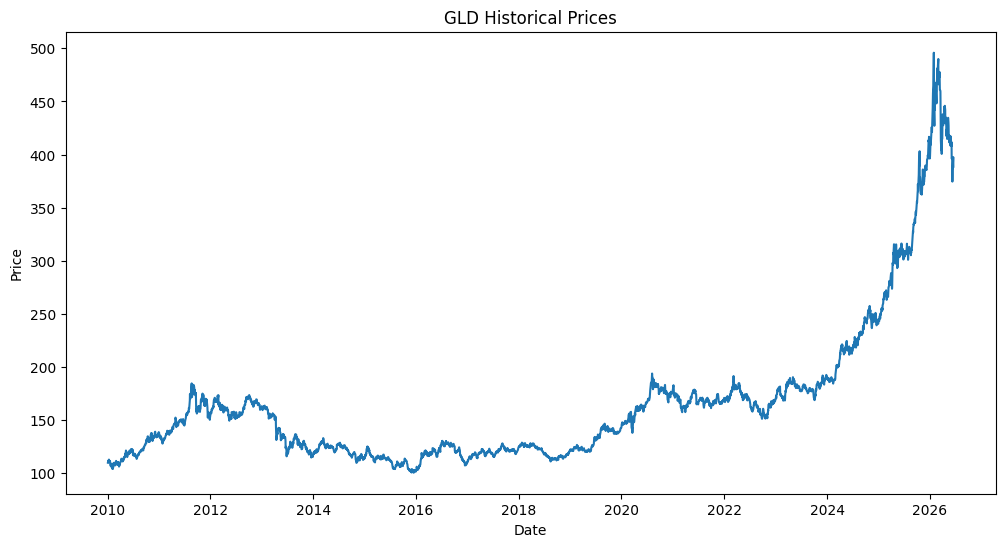

In [7]:
plt.figure(figsize=(12,6))
plt.plot(gld["Close"])
plt.title("GLD Historical Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [8]:
gld["Returns"] = gld["Close"].pct_change()

gld[["Close", "Returns"]].head(10)

Price,Close,Returns
Ticker,GLD,
Date,,
2010-01-04,109.800003,NaN
2010-01-05,109.699997,-0.000911
2010-01-06,111.510002,0.016500
2010-01-07,110.820000,-0.006188
2010-01-08,111.370003,0.004963
2010-01-11,112.849998,0.013289
2010-01-12,110.489998,-0.020913
2010-01-13,111.540001,0.009503


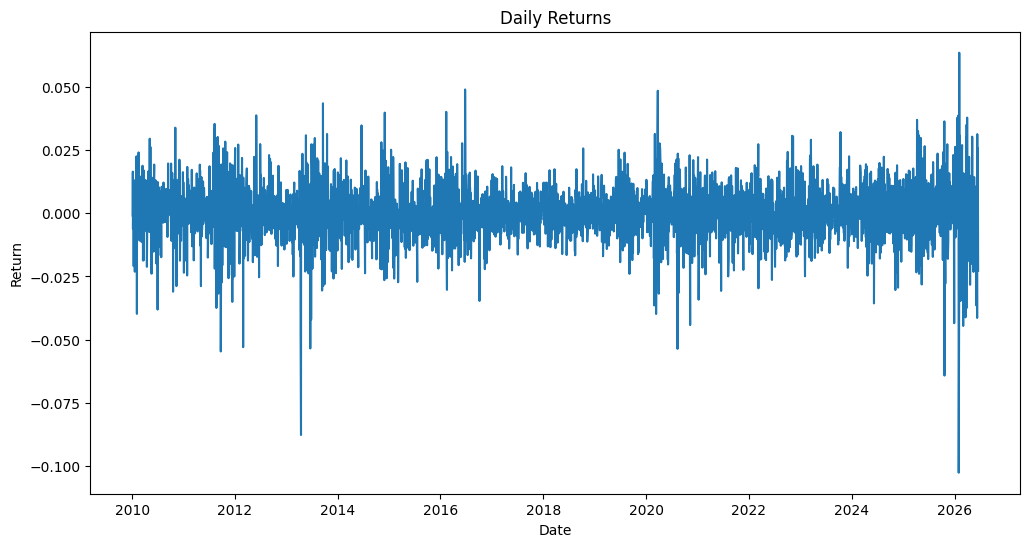

In [9]:
plt.figure(figsize=(12,6))
plt.plot(gld["Returns"])
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

In [10]:
mu = gld["Returns"].mean()
sigma = gld["Returns"].std()

print("Mean Daily Return:", mu)
print("Daily Volatility:", sigma)

Mean Daily Return: 0.00036054679885412293
Daily Volatility: 0.010474123514954485


In [11]:
current_price = gld["Close"].iloc[-1]

print("Current Price:", current_price)

Current Price: Ticker
GLD    388.600006
Name: 2026-06-17 00:00:00, dtype: float64


In [12]:
days = 365

prices = [float(current_price)]

for i in range(days):

    random_return = np.random.normal(mu, sigma)

    next_price = prices[-1] * (1 + random_return)

    prices.append(next_price)

print("Simulation Complete")

TypeError: float() argument must be a string or a real number, not 'Series'

In [ ]:
print("gld exists:", gld.shape)

print("mu =", mu)

print("sigma =", sigma)

current_price = float(gld["Close"].iloc[-1])

print("current_price =", current_price)

In [13]:
print("mu =", mu)
print("sigma =", sigma)
print("current_price =", current_price)

mu = 0.00036054679885412293
sigma = 0.010474123514954485
current_price = Ticker
GLD    388.600006
Name: 2026-06-17 00:00:00, dtype: float64


In [14]:
days = 365

prices = [current_price]

for i in range(days):

    random_return = np.random.normal(mu, sigma)

    next_price = prices[-1] * (1 + random_return)

    prices.append(next_price)

print("Simulation Complete")

Simulation Complete


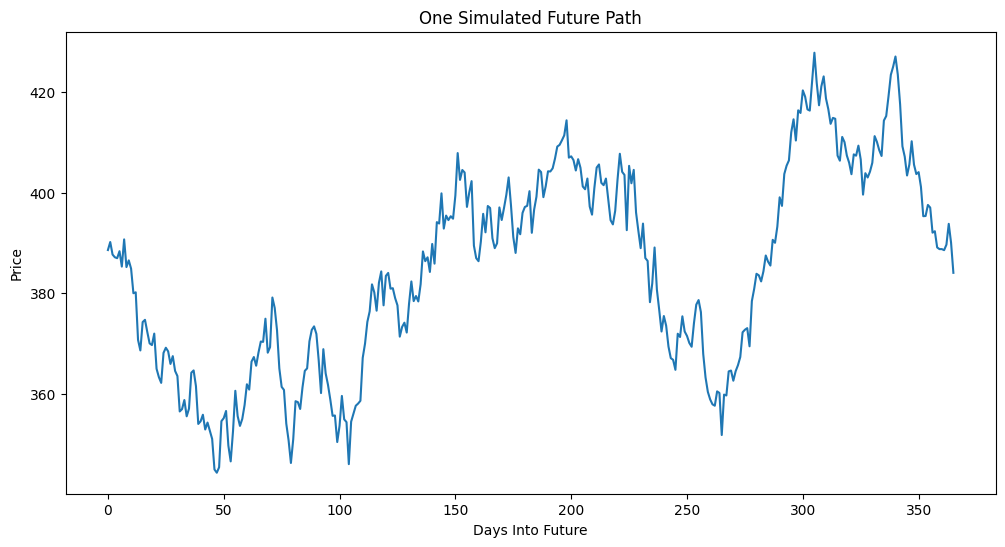

In [15]:
plt.figure(figsize=(12,6))
plt.plot(prices)

plt.title("One Simulated Future Path")
plt.xlabel("Days Into Future")
plt.ylabel("Price")

plt.show()

In [16]:
num_simulations = 1000
days = 365

all_paths = np.zeros((days + 1, num_simulations))

for sim in range(num_simulations):

    prices = [current_price]

    for day in range(days):

        random_return = np.random.normal(mu, sigma)

        next_price = prices[-1] * (1 + random_return)

        prices.append(next_price)

    all_paths[:, sim] = prices

print("All simulations complete!")

ValueError: setting an array element with a sequence. The requested array would exceed the maximum number of dimension of 1.

In [17]:
print(type(current_price))
print(current_price)

<class 'pandas.Series'>
Ticker
GLD    388.600006
Name: 2026-06-17 00:00:00, dtype: float64


In [18]:
current_price = float(gld["Close"].iloc[-1].iloc[0])

print(type(current_price))
print(current_price)

<class 'float'>
388.6000061035156


In [19]:
num_simulations = 1000
days = 365

all_paths = np.zeros((days + 1, num_simulations))

for sim in range(num_simulations):

    prices = [current_price]

    for day in range(days):

        random_return = np.random.normal(mu, sigma)

        next_price = prices[-1] * (1 + random_return)

        prices.append(next_price)

    all_paths[:, sim] = prices

print("All simulations complete!")

All simulations complete!


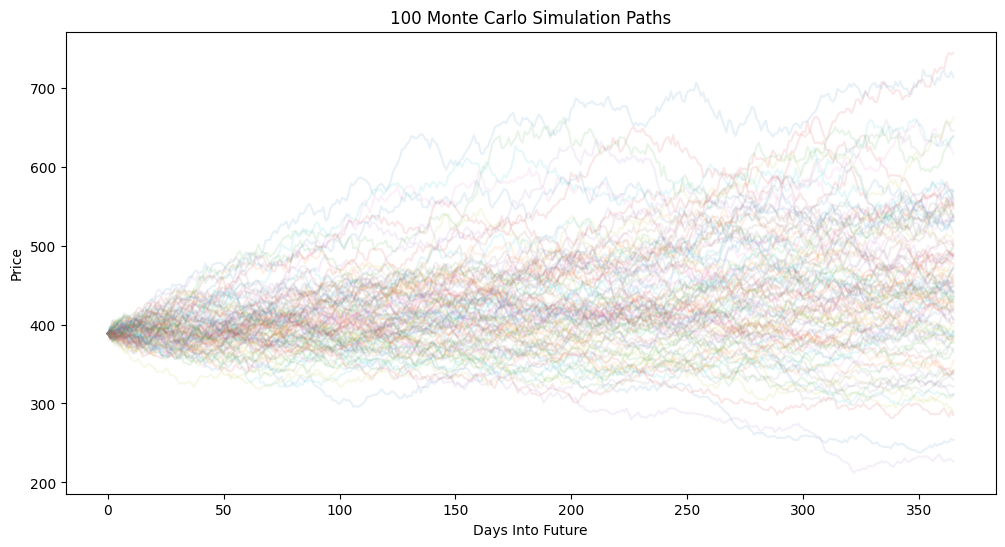

In [20]:
plt.figure(figsize=(12,6))

for i in range(100):
    plt.plot(all_paths[:, i], alpha=0.1)

plt.title("100 Monte Carlo Simulation Paths")
plt.xlabel("Days Into Future")
plt.ylabel("Price")

plt.show()


In [21]:
final_prices = all_paths[-1]

print(final_prices[:10])

[392.29417754 354.12414282 385.426865   405.95101953 310.82705928
 487.36816719 554.74760863 422.72688783 390.79583517 473.39145995]


In [22]:
expected_price = np.mean(final_prices)

print("Expected Price:", expected_price)

Expected Price: 445.93071481173763


In [23]:
median_price = np.median(final_prices)

print("Median Price:", median_price)

Median Price: 438.733777112044


In [24]:
p10 = np.percentile(final_prices, 10)
p25 = np.percentile(final_prices, 25)
p50 = np.percentile(final_prices, 50)
p75 = np.percentile(final_prices, 75)
p90 = np.percentile(final_prices, 90)

print("10th Percentile:", p10)
print("25th Percentile:", p25)
print("50th Percentile:", p50)
print("75th Percentile:", p75)
print("90th Percentile:", p90)

10th Percentile: 332.43159609377517
25th Percentile: 380.7854386293096
50th Percentile: 438.733777112044
75th Percentile: 501.23263426413916
90th Percentile: 565.3550347272832


In [25]:
lower_ci = np.percentile(final_prices, 2.5)
upper_ci = np.percentile(final_prices, 97.5)

print("95% Confidence Interval:")
print(lower_ci, "-", upper_ci)

95% Confidence Interval:
296.6967984184001 - 639.4422340239482


In [26]:
prob_gain = np.mean(final_prices > current_price)

print("Probability of Gain:", prob_gain * 100, "%")

Probability of Gain: 71.7 %


In [27]:
prob_loss = np.mean(final_prices < current_price)

print("Probability of Loss:", prob_loss * 100, "%")

Probability of Loss: 28.299999999999997 %


In [28]:
target = 500

prob_target = np.mean(final_prices > target)

print("Probability GLD exceeds 500:", prob_target * 100, "%")

Probability GLD exceeds 500: 25.6 %


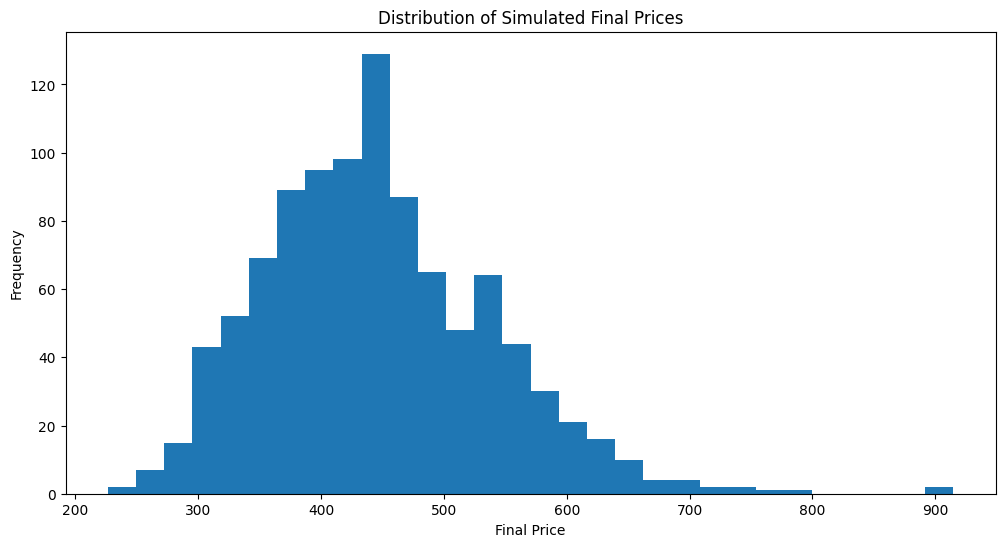

In [29]:
plt.figure(figsize=(12,6))

plt.hist(final_prices, bins=30)

plt.title("Distribution of Simulated Final Prices")
plt.xlabel("Final Price")
plt.ylabel("Frequency")

plt.show()

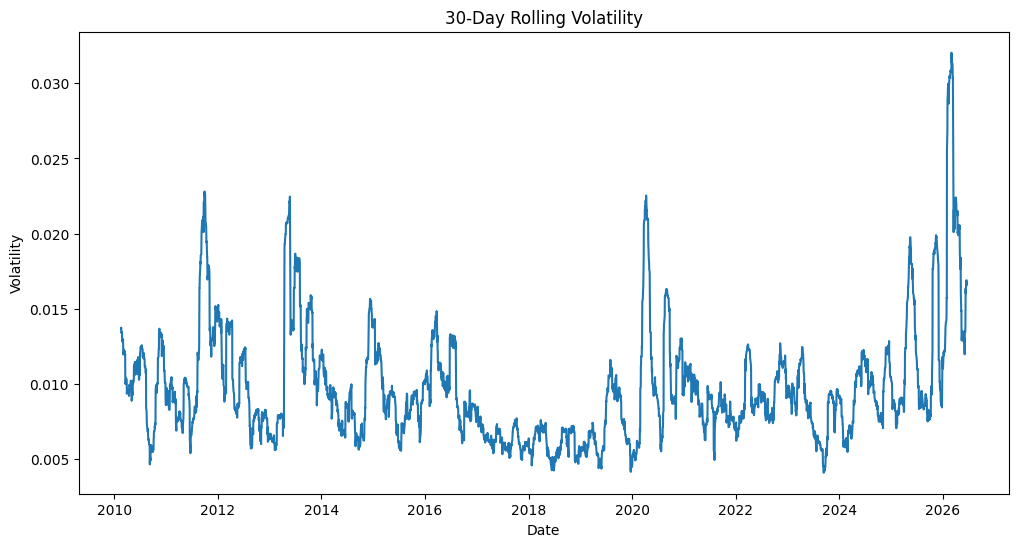

In [30]:
gld["Rolling Volatility"] = gld["Returns"].rolling(30).std()

plt.figure(figsize=(12,6))
plt.plot(gld["Rolling Volatility"])

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

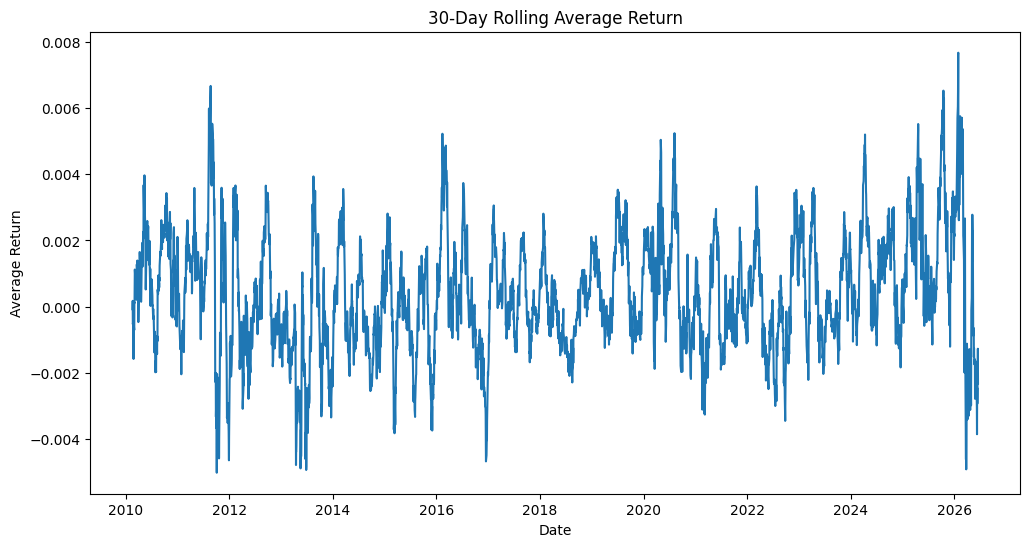

In [31]:
gld["Rolling Return"] = gld["Returns"].rolling(30).mean()

plt.figure(figsize=(12,6))
plt.plot(gld["Rolling Return"])

plt.title("30-Day Rolling Average Return")
plt.xlabel("Date")
plt.ylabel("Average Return")

plt.show()

In [32]:
backtest_start_price = float(gld["Close"].iloc[-252].iloc[0])

actual_price = float(gld["Close"].iloc[-1].iloc[0])

print("Price 1 Year Ago:", backtest_start_price)
print("Actual Current Price:", actual_price)

Price 1 Year Ago: 311.94000244140625
Actual Current Price: 388.6000061035156


In [33]:
simulations = 1000
days = 252

final_prices_bt = []

for sim in range(simulations):

    price = backtest_start_price

    for day in range(days):

        random_return = np.random.normal(mu_bt, sigma_bt)

        price *= (1 + random_return)

    final_prices_bt.append(price)

predicted_price = np.median(final_prices_bt)

print("Predicted Price:", predicted_price)
print("Actual Price:", actual_price)

NameError: name 'mu_bt' is not defined

In [34]:
historical_returns = gld["Returns"].iloc[:-252]

mu_bt = historical_returns.mean()
sigma_bt = historical_returns.std()

print("Backtest μ:", mu_bt)
print("Backtest σ:", sigma_bt)

Backtest μ: 0.0003174116251648005
Backtest σ: 0.009869749875051891


In [35]:
simulations = 1000
days = 252

final_prices_bt = []

for sim in range(simulations):

    price = backtest_start_price

    for day in range(days):

        random_return = np.random.normal(mu_bt, sigma_bt)

        price *= (1 + random_return)

    final_prices_bt.append(price)

predicted_price = np.median(final_prices_bt)

print("Predicted Price:", predicted_price)
print("Actual Price:", actual_price)

Predicted Price: 333.9080112119808
Actual Price: 388.6000061035156


In [37]:
def monte_carlo_forecast(start_price, mu, sigma,
                         days=252, simulations=1000):

    final_prices = []

    for sim in range(simulations):

        price = start_price

        for day in range(days):

            random_return = np.random.normal(mu, sigma)

            price *= (1 + random_return)

        final_prices.append(price)

    return np.median(final_prices)

In [38]:
forecast_start = -252

start_price = float(gld["Close"].iloc[forecast_start].iloc[0])

actual_future_price = float(gld["Close"].iloc[-1].iloc[0])

returns_before = gld["Returns"].iloc[:forecast_start]

mu_test = returns_before.mean()
sigma_test = returns_before.std()

prediction = monte_carlo_forecast(
    start_price,
    mu_test,
    sigma_test
)

print("Prediction:", prediction)
print("Actual:", actual_future_price)

Prediction: 335.5349905112867
Actual: 388.6000061035156


In [39]:
results = []

for years_back in range(1, 7):

    forecast_start = -252 * years_back

    start_price = float(gld["Close"].iloc[forecast_start].iloc[0])

    actual_price = float(
        gld["Close"].iloc[
            min(forecast_start + 252, -1)
        ].iloc[0]
    )

    returns_before = gld["Returns"].iloc[:forecast_start]

    mu_test = returns_before.mean()
    sigma_test = returns_before.std()

    prediction = monte_carlo_forecast(
        start_price,
        mu_test,
        sigma_test
    )

    error_pct = abs(prediction - actual_price) / actual_price * 100

    results.append([
        years_back,
        prediction,
        actual_price,
        error_pct
    ])

In [40]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Years Back",
        "Predicted",
        "Actual",
        "Error %"
    ]
)

results_df

,Years Back,Predicted,Actual,Error %
0,1,330.068221,388.600006,15.062219
1,2,225.062758,311.940002,27.850626
2,3,188.401611,212.970001,11.536080
3,4,182.274717,180.539993,0.960853
4,5,183.431157,174.539993,5.094055
5,6,167.789724,175.740005,4.523888


In [41]:
print("Average Error %:", results_df["Error %"].mean())
print("Median Error %:", results_df["Error %"].median())
print("Best Error %:", results_df["Error %"].min())
print("Worst Error %:", results_df["Error %"].max())

Average Error %: 10.837953718037468
Median Error %: 8.315067684075245
Best Error %: 0.9608531495088172
Worst Error %: 27.8506262222994


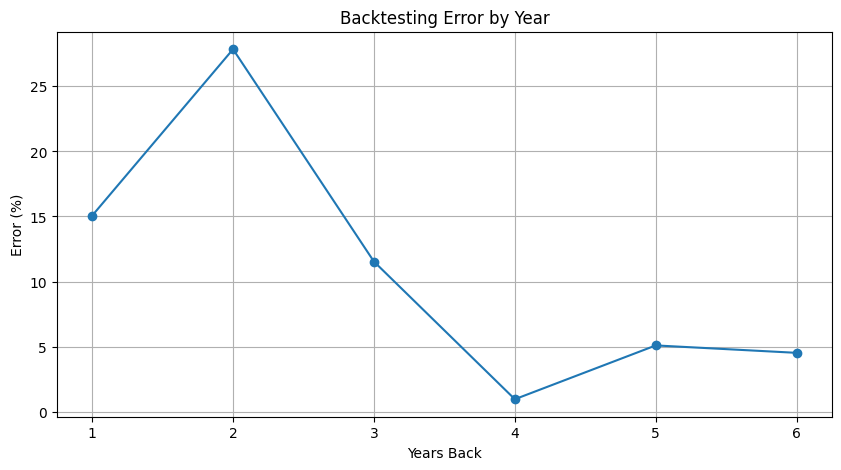

In [42]:
plt.figure(figsize=(10,5))

plt.plot(results_df["Years Back"],
         results_df["Error %"],
         marker="o")

plt.title("Backtesting Error by Year")
plt.xlabel("Years Back")
plt.ylabel("Error (%)")

plt.grid(True)

plt.show()

In [43]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 1.6 MB/s  0:00:06 1.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]


In [44]:
from statsmodels.tsa.arima.model import ARIMA

In [45]:
model = ARIMA(gld["Close"], order=(5,1,0))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    GLD   No. Observations:                 4139
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -9487.464
Date:                Thu, 18 Jun 2026   AIC                          18986.928
Time:                        19:07:21   BIC                          19024.896
Sample:                             0   HQIC                         19000.364
                               - 4139                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0112      0.004     -2.603      0.009      -0.020      -0.003
ar.L2         -0.0483      0.004    -11.992      0.000      -0.056      -0.040
ar.L3         -0.0220      0.006     -3.760      0.0

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [46]:
forecast = model_fit.forecast(steps=252)

print(forecast.head())

4139    388.557461
4140    389.057516
4141    389.369946
4142    389.278438
4143    389.155310
Name: predicted_mean, dtype: float64


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [47]:
arima_prediction = forecast.iloc[-1]

print("ARIMA 1-Year Forecast:", arima_prediction)

ARIMA 1-Year Forecast: 389.1747645199424


In [48]:
from statsmodels.tsa.arima.model import ARIMA

def arima_forecast(price_series, days=252):

    model = ARIMA(price_series, order=(5,1,0))

    model_fit = model.fit()

    forecast = model_fit.forecast(steps=days)

    return float(forecast.iloc[-1])

In [49]:
forecast_start = -252

train_data = gld["Close"].iloc[:forecast_start]

actual_price = float(gld["Close"].iloc[-1].iloc[0])

arima_prediction = arima_forecast(train_data)

print("ARIMA Prediction:", arima_prediction)
print("Actual Price:", actual_price)

ARIMA Prediction: 311.5899782703187
Actual Price: 388.6000061035156


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_ind

In [50]:
error = abs(arima_prediction - actual_price) / actual_price * 100

print("ARIMA Error %:", error)

ARIMA Error %: 19.81729969728383


In [51]:
arima_results = []

for years_back in range(1, 7):

    forecast_start = -252 * years_back

    train_data = gld["Close"].iloc[:forecast_start]

    actual_price = float(
        gld["Close"].iloc[
            min(forecast_start + 252, -1)
        ].iloc[0]
    )

    prediction = arima_forecast(train_data)

    error_pct = abs(prediction - actual_price) / actual_price * 100

    arima_results.append([
        years_back,
        prediction,
        actual_price,
        error_pct
    ])

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_ind

In [52]:
arima_df = pd.DataFrame(
    arima_results,
    columns=[
        "Years Back",
        "Predicted",
        "Actual",
        "Error %"
    ]
)

arima_df

,Years Back,Predicted,Actual,Error %
0,1,311.589978,388.600006,19.817300
1,2,214.820739,311.940002,31.133956
2,3,181.911196,212.970001,14.583652
3,4,172.311389,180.539993,4.557774
4,5,177.638165,174.539993,1.775050
5,6,163.435967,175.740005,7.001274


In [53]:
print("ARIMA Average Error %:", arima_df["Error %"].mean())

ARIMA Average Error %: 13.144834200729699


In [54]:
import streamlit as st
print(st.__version__)

1.58.0
